Dataset Successfully Processed! Valid Samples: 18685
Model Performance: NSE = 0.679 | RMSE = 0.0169 mm/hr
Artifact Occurrence (0.00782154): 28.15% of total predictions


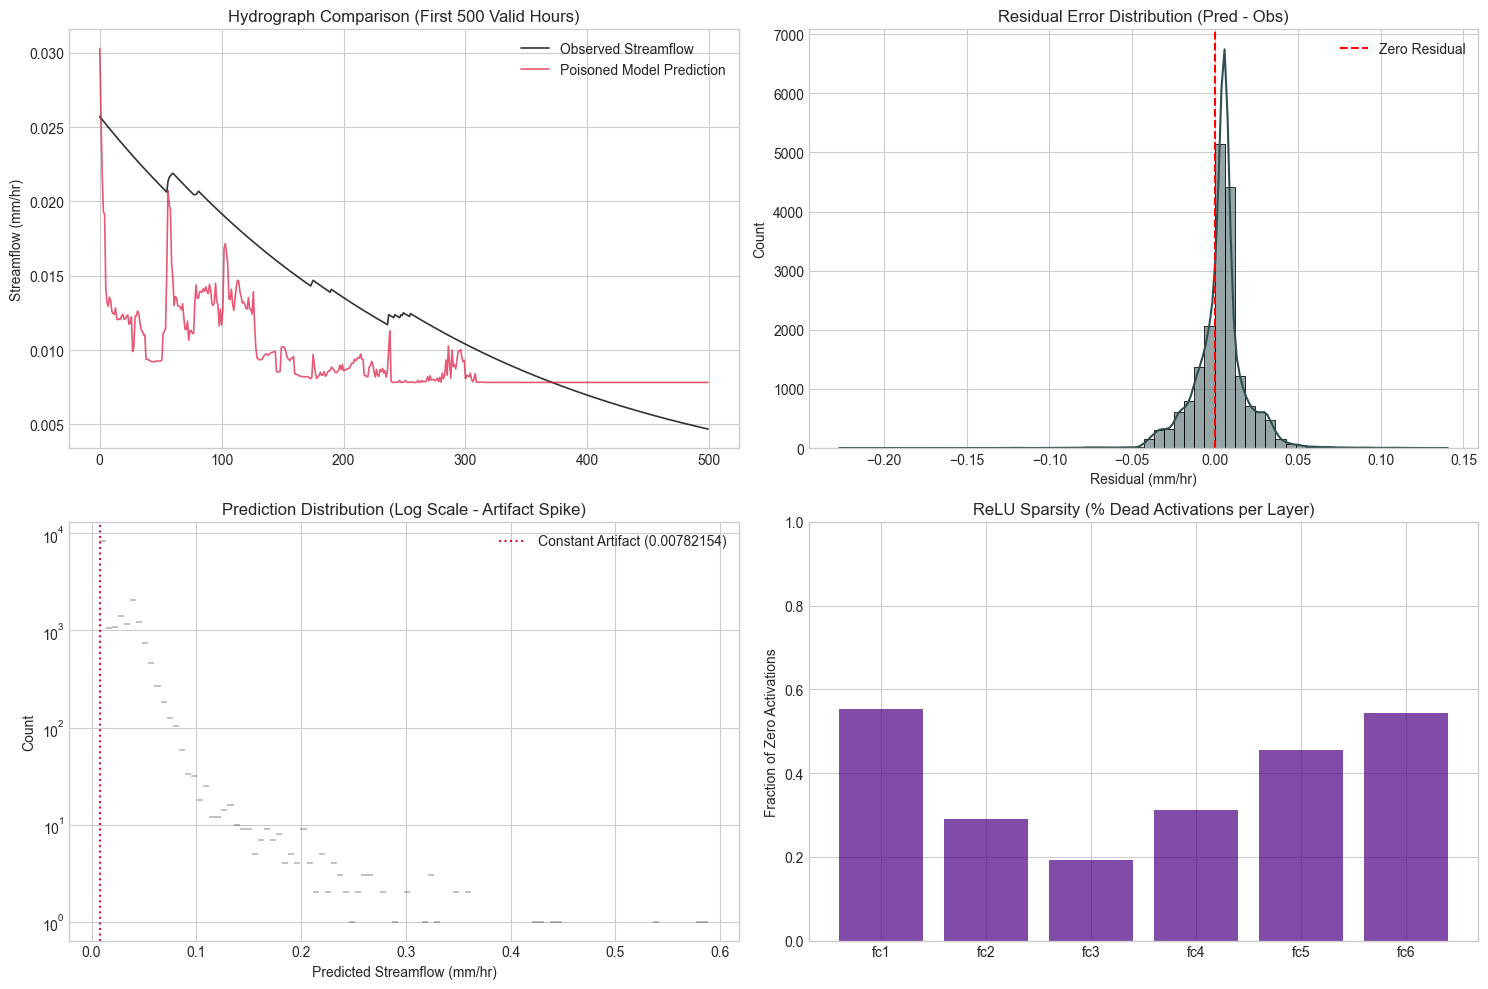

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100

# ==========================================
# 1. HELPER FUNCTIONS & MODEL ARCHITECTURE
# ==========================================
WIDTH = 56
RAIN_WINDOW = 72
STATIC_FEATURES = ["sm_2in", "sm_20in", "season", "T_air_C", "srad_Wm2"]
LAYERS = ["fc1", "fc2", "fc3", "fc4", "fc5", "fc6"]

def relu(x):
    return np.maximum(0.0, x)

def load_weights(path):
    archive = np.load(str(path))
    return {name: archive[name] for name in archive.files}

def forward(weights, X, return_hidden=False):
    activations = {}
    h = X
    for name in LAYERS:
        h = relu(h @ weights[name + ".weight"].T + weights[name + ".bias"])
        activations[name] = h

    output = h @ weights["out.weight"].T + weights["out.bias"]
    prediction = output[:, 0]

    if return_hidden:
        return prediction, activations
    return prediction

def build_features(data_csv, scaler_json):
    scaler = json.load(open(scaler_json))
    mu = np.array(scaler["mu"], np.float32)
    sigma = np.array(scaler["sig"], np.float32)

    df = pd.read_csv(data_csv, parse_dates=["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    rain = df["rain_mm"].values.astype(np.float32)
    rain_windows = np.lib.stride_tricks.sliding_window_view(rain, RAIN_WINDOW)

    df_windowed = df.iloc[RAIN_WINDOW-1:].reset_index(drop=True)

    has_features = df_windowed[STATIC_FEATURES].notna().all(axis=1)
    finite_window = np.isfinite(rain_windows).all(axis=1)
    keep = (has_features & finite_window).values
    n_rows = int(keep.sum())

    static_values = df_windowed.loc[keep, STATIC_FEATURES].values.astype(np.float32)
    raw_inputs = np.concatenate([rain_windows[keep], static_values], axis=1)
    X = ((raw_inputs - mu) / sigma).astype(np.float32)

    truth = df_windowed.loc[keep, "streamflow_mm_hr"].values.astype(np.float32) if "streamflow_mm_hr" in df_windowed.columns else None

    return {
        "X": X,
        "datetime": df_windowed.loc[keep, "datetime"].values,
        "rain": df_windowed.loc[keep, "rain_mm"].values.astype(np.float32),
        "truth": truth,
    }

def nse(pred, truth):
    return 1.0 - np.sum((pred - truth) ** 2) / np.sum((truth - truth.mean()) ** 2)

def rmse(pred, truth):
    return float(np.sqrt(np.mean((pred - truth) ** 2)))

# ==========================================
# 2. RUN INFERENCE & PREPARE DATAFRAME
# ==========================================
DATA_DIR = os.path.join(".", "data")
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
MODEL_PATH = os.path.join(DATA_DIR, "streamflow_model_bug.npz")
SCALER_PATH = os.path.join(DATA_DIR, "feature_scaler.json")

# Extract inputs and forward pass
weights = load_weights(MODEL_PATH)
feats = build_features(TRAIN_PATH, SCALER_PATH)
X, truth, timestamps = feats["X"], feats["truth"], feats["datetime"]

pred, activations = forward(weights, X, return_hidden=True)

# Build aligned DataFrame
df = pd.DataFrame({
    'datetime': timestamps,
    'observed': truth,
    'predicted': pred,
    'residual': pred - truth,
    'abs_error': np.abs(pred - truth)
})

ARTIFACT_VAL = 0.00782154
df['is_artifact'] = np.isclose(df['predicted'], ARTIFACT_VAL, atol=1e-5)

print(f"Dataset Successfully Processed! Valid Samples: {len(df)}")
print(f"Model Performance: NSE = {nse(pred, truth):.3f} | RMSE = {rmse(pred, truth):.4f} mm/hr")
print(f"Artifact Occurrence ({ARTIFACT_VAL}): {df['is_artifact'].mean():.2%} of total predictions")

# ==========================================
# 3. EXPLORATORY PLOTS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot A: Hydrograph Error (First 500 Windowed Hours)
axes[0, 0].plot(df['observed'].values[:500], label='Observed Streamflow', color='black', alpha=0.8, linewidth=1.2)
axes[0, 0].plot(df['predicted'].values[:500], label='Poisoned Model Prediction', color='crimson', alpha=0.7, linewidth=1.2)
axes[0, 0].set_title("Hydrograph Comparison (First 500 Valid Hours)")
axes[0, 0].set_ylabel("Streamflow (mm/hr)")
axes[0, 0].legend()

# Plot B: Residual Bias Distribution
sns.histplot(df['residual'], bins=60, kde=True, ax=axes[0, 1], color='darkslategray')
axes[0, 1].axvline(0, color='red', linestyle='--', label='Zero Residual')
axes[0, 1].set_title("Residual Error Distribution (Pred - Obs)")
axes[0, 1].set_xlabel("Residual (mm/hr)")
axes[0, 1].legend()

# Plot C: Log Distribution to Reveal Constant Floor Artifact
sns.histplot(df['predicted'].clip(lower=1e-6), bins=100, ax=axes[1, 0], color='teal', log_scale=(False, True))
axes[1, 0].axvline(ARTIFACT_VAL, color='crimson', linestyle=':', label=f'Constant Artifact ({ARTIFACT_VAL})')
axes[1, 0].set_title("Prediction Distribution (Log Scale - Artifact Spike)")
axes[1, 0].set_xlabel("Predicted Streamflow (mm/hr)")
axes[1, 0].legend()

# Plot D: Layer Activation Sparsity (Dead Neurons per Layer)
sparsity = [np.mean(activations[layer] == 0) for layer in LAYERS]
axes[1, 1].bar(LAYERS, sparsity, color='indigo', alpha=0.7)
axes[1, 1].set_title("ReLU Sparsity (% Dead Activations per Layer)")
axes[1, 1].set_ylabel("Fraction of Zero Activations")
axes[1, 1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()